<a href="https://colab.research.google.com/github/drmamckinney/Week2-GitHub-MarkMcKinney/blob/main/Guided_Lab_6_1_Detecting_Suspicious_Cybersecurity_Behavior_Mark_McKinney.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Guided Lab 6.1 – Detecting Suspicious Cybersecurity Behavior with Machine Learning

Mark McKinney

This lab applies machine learning techniques to identify suspicious or fraudulent activity using a cybersecurity-focused fraud detection dataset. The analysis includes data exploration, model training, performance evaluation, visualization, and interpretation of findings in a cybersecurity context.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [21]:
# Load the fraud detection dataset
df = pd.read_csv("creditcard-7.csv")

# Display the first five records
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [22]:
# Review the dataset structure
print("Dataset Shape:")
print(df.shape)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Examine fraud vs. normal transaction distribution
print("\nClass Distribution:")
print(df["Class"].value_counts())

Dataset Shape:
(284807, 31)

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


## Dataset Exploration

The dataset contains normal and fraudulent transactions.

Class = 0 indicates a normal transaction.

Class = 1 indicates a fraudulent transaction.

This dataset simulates anomaly detection and suspicious activity monitoring commonly used in cybersecurity systems.

In [23]:
# Define features and target variable
X = df.drop("Class", axis=1)
y = df["Class"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Standardize the feature values
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preparation complete.")

Data preparation complete.


In [24]:
# Train the Logistic Regression model
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

print("Model training complete.")

Model training complete.


In [25]:
# Generate predictions using the trained model
y_pred = model.predict(
    X_test_scaled
)

# Display classification results
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [26]:
# Calculate model evaluation metrics

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9991397773954567
Precision: 0.8266666666666667
Recall: 0.6326530612244898
F1 Score: 0.7167630057803468


In [27]:
# Create the confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[56851    13]
 [   36    62]]


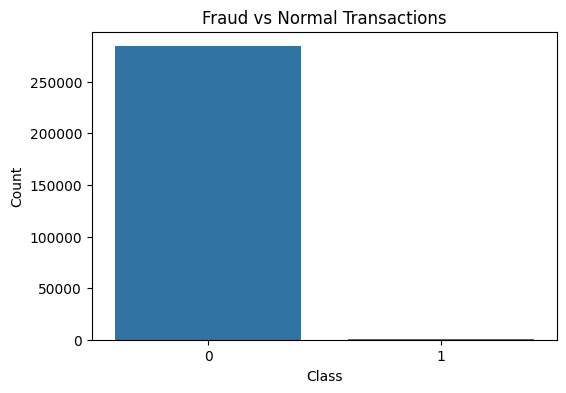

In [28]:
# Visualize fraud versus normal transactions

plt.figure(figsize=(6,4))

sns.countplot(
    x="Class",
    data=df
)

plt.title("Fraud vs Normal Transactions")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

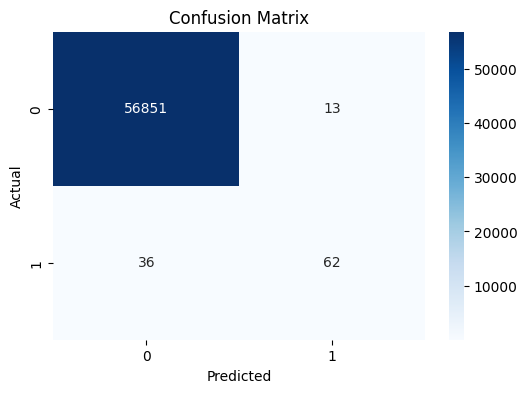

In [29]:
# Visualize model performance using a confusion matrix heatmap

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Interpretation of Findings

The machine learning model demonstrated strong overall performance in identifying fraudulent and legitimate transactions. The model achieved an accuracy of approximately 99.91%, indicating that it correctly classified the vast majority of transactions. The precision score of 82.67% suggests that most transactions identified as fraudulent were actually fraudulent. The recall score of 63.27% indicates that the model successfully detected many fraudulent transactions but still failed to identify some suspicious activity. The F1 score of 71.68% reflects a reasonable balance between precision and recall.

The confusion matrix revealed that 56,851 legitimate transactions and 62 fraudulent transactions were correctly classified. However, 13 legitimate transactions were incorrectly flagged as fraud, while 36 fraudulent transactions were missed by the model. These results demonstrate the challenges associated with detecting rare fraudulent events and highlight the importance of balancing detection accuracy with minimizing false alarms.

Overall, the model illustrates how machine learning can support cybersecurity monitoring, fraud detection, and threat identification by analyzing large volumes of transaction data and identifying potentially suspicious behavior.


## Reflection Questions

### 1. How accurate was the machine learning model?

The machine learning model achieved an accuracy of approximately 99.91%, indicating that it correctly classified nearly all transactions within the dataset. This demonstrates that the model was highly effective at distinguishing between normal and fraudulent activity.

### 2. What types of suspicious behavior were identified?

The model identified transactions exhibiting characteristics commonly associated with fraudulent behavior. These transactions differed from normal transaction patterns and were classified as potentially suspicious or fraudulent.

### 3. What do precision and recall tell us about threat detection performance?

Precision measures how many of the transactions flagged as fraudulent were actually fraudulent. The model achieved a precision score of 82.67%, indicating a relatively low number of false alarms. Recall measures the model's ability to identify fraudulent transactions. The recall score of 63.27% indicates that some fraudulent transactions were successfully detected, while others were missed.

### 4. What does the confusion matrix reveal about the model?

The confusion matrix shows that the model correctly classified 56,851 legitimate transactions and 62 fraudulent transactions. It also revealed 13 false positives and 36 false negatives. This demonstrates that while the model performed well overall, some fraudulent transactions were not detected.

### 5. Why are false negatives dangerous in cybersecurity systems?

False negatives are dangerous because malicious activity is incorrectly classified as normal activity. In cybersecurity environments, missed threats may allow fraud, unauthorized access, or other malicious actions to continue undetected, increasing organizational risk.

### 6. How can machine learning improve cybersecurity monitoring?

Machine learning can analyze large volumes of security data more quickly than manual methods. It can identify suspicious patterns, detect anomalies, prioritize alerts, and assist cybersecurity analysts in identifying potential threats more efficiently.

### 7. What are some limitations of AI-driven cybersecurity systems?

AI-driven cybersecurity systems may generate false positives and false negatives, rely on the quality of available data, and struggle to identify previously unseen attack techniques. Human oversight remains important to validate findings, investigate alerts, and make informed security decisions.
